### This notebook is reformed, the first part is from an old analysis of empirical p-values, the second is a new one using t to z conversion (for plots sake), stouffer method for p val aggregation, maybe add it to fisher

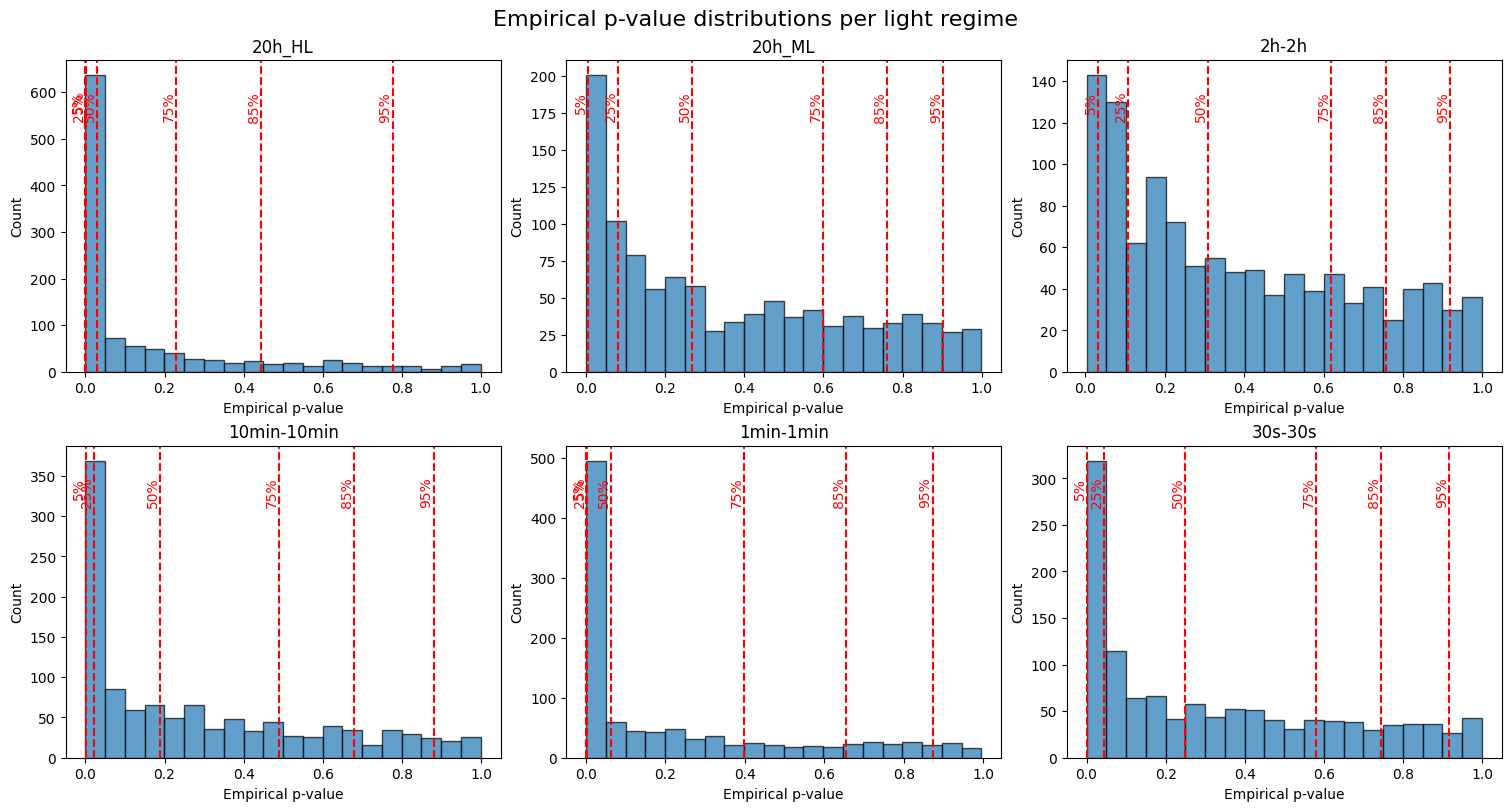

In [14]:
import matplotlib.pyplot as plt
import numpy as np

light_regimes = ['20h_HL', '20h_ML', '2h-2h', '10min-10min', '1min-1min', '30s-30s']
n = len(light_regimes)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 4), constrained_layout=True)
axes = axes.flatten()

for i, light in enumerate(light_regimes):
    ax = axes[i]
    pvals = empirical_pvals_df[empirical_pvals_df['light_regime'] == light]['empirical_p_value'].dropna()

    ax.hist(pvals, bins=20, edgecolor='black', alpha=0.7)
    ax.set_title(light)
    ax.set_xlabel('Empirical p-value')
    ax.set_ylabel('Count')

    for q in [5, 25, 50, 75, 85, 95]:
        perc = np.percentile(pvals, q)
        ax.axvline(perc, color='red', linestyle='--')
        ax.text(perc, ax.get_ylim()[1]*0.9, f'{q}%', rotation=90, color='red', va='top', ha='right')

# Supprimer les cases vides si le nombre de régimes est < 9
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Empirical p-value distributions per light regime', fontsize=16)
plt.show()


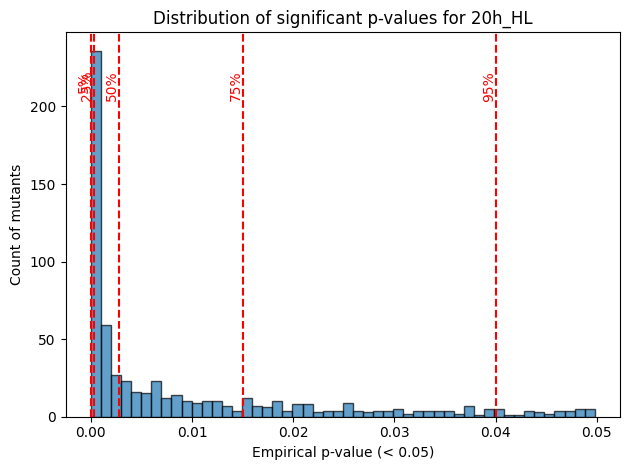

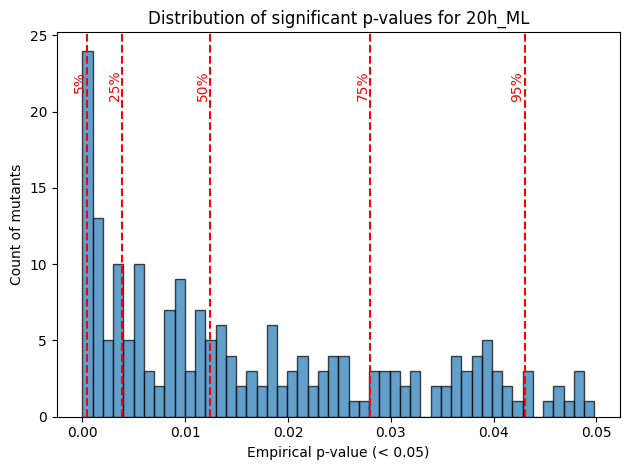

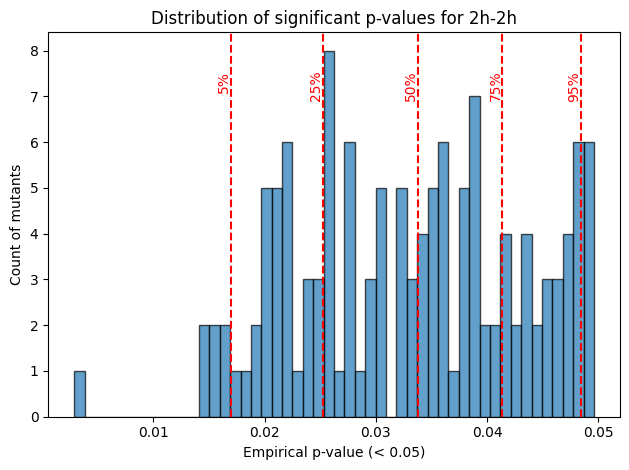

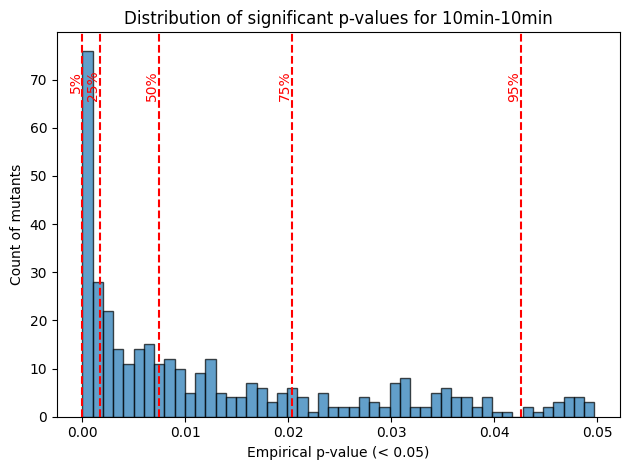

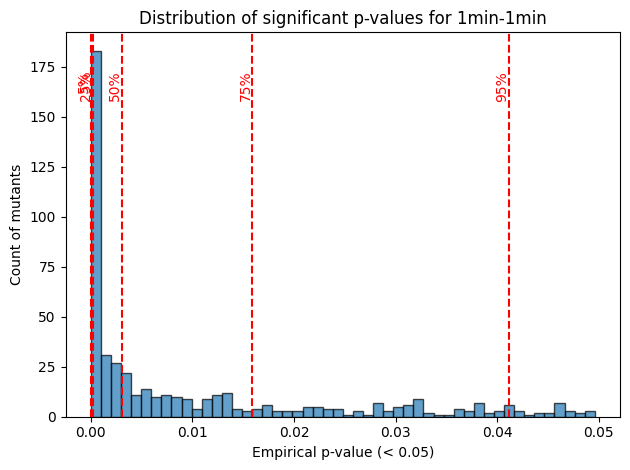

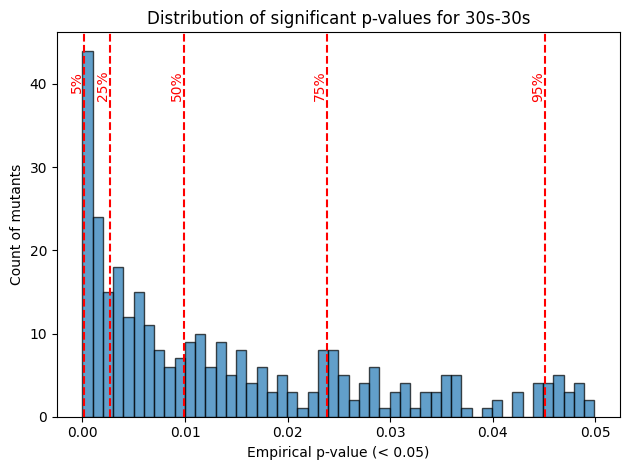

In [15]:
import matplotlib.pyplot as plt
import numpy as np

light_regimes = ['20h_HL', '20h_ML', '2h-2h', '10min-10min', '1min-1min', '30s-30s']

for light in light_regimes:
    # Filter for p-values < 0.05
    pvals = empirical_pvals_df[
        (empirical_pvals_df['light_regime'] == light) &
        (empirical_pvals_df['empirical_p_value'] < 0.05)
    ]['empirical_p_value']

    if pvals.empty:
        print(f"No p-values < 0.05 for {light}")
        continue

    # Plot histogram with more bins
    plt.hist(pvals, bins=50, edgecolor='black', alpha=0.7)
    plt.xlabel('Empirical p-value (< 0.05)')
    plt.ylabel('Count of mutants')
    plt.title(f'Distribution of significant p-values for {light}')

    # Add percentile lines
    for q in [5, 25, 50, 75, 95]:
        perc = np.percentile(pvals, q)
        plt.axvline(perc, color='red', linestyle='--')
        plt.text(perc, plt.ylim()[1]*0.9, f'{q}%', rotation=90, color='red', va='top', ha='right')

    plt.tight_layout()
    plt.show()


In [ ]:
# empirical_pvals_df.to_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/empirical_pvals_PHASE2.csv', index=False)

### Mutant z scores and stouffer analyis

focus rn only on phase 2 and then we'll 

In [1]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_1samp, norm
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt

data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/2025_5_phase2_light_status_slope.csv')
#data['y2_slope'] ==data['y2_slope_mixed_centered']
def mutant_level_pvals(mutants_df, wt_df, regime):
    records = []
    mut_sub = mutants_df[mutants_df['light_regime'] == regime]
    wt_sub = wt_df[wt_df['light_regime'] == regime]
    
    for _, row in mut_sub.iterrows():
        mutant_id = row['mutant_ID']
        gene = row['mutated_genes']
        plate = row['plate']
        mutant_slope = row['y2_slope']
        wt_slopes = wt_sub[wt_sub['plate'] == plate]['y2_slope'].values
        
        if len(wt_slopes) < 2:
            continue
        
        t_stat, p_val = ttest_1samp(wt_slopes, popmean=mutant_slope)
        p_val = max(p_val, 1e-300)
        z = np.sign(np.mean(wt_slopes) - mutant_slope) * norm.ppf(1 - p_val/2)
        
        records.append({
            'mutant_ID': mutant_id,
            'mutated_genes': gene,
            'y2_slope': mutant_slope,
            'plate': plate,
            'light_regime': regime,
            'p_value': p_val,
            'z_score': z
        })
        
    return pd.DataFrame(records)
def gene_level_stouffer(mutant_plate_df):
    mutant_counts = mutant_plate_df.groupby('mutant_ID').size().to_dict()
    
    gene_records = []
    for gene, group in mutant_plate_df.groupby('mutated_genes'):
        pvals = group['p_value'].values
        zscores = group['z_score'].values
        weights = 1/group['mutant_ID'].map(mutant_counts).values
        
        #weighted_z = np.sum(weights * zscores) / np.sqrt(np.sum(weights**2))
        weighted_z = np.sum(zscores) / np.sqrt(len(zscores))
        combined_p = 2 * norm.sf(abs(weighted_z))
        
        gene_records.append({
            'gene': gene,
            'combined_z': weighted_z,
            'combined_p': combined_p
        })
    
    gene_df = pd.DataFrame(gene_records)
    _, fdr_pvals, _, _ = multipletests(gene_df['combined_p'], method='fdr_bh')
    gene_df['FDR_p_value'] = fdr_pvals
    
    return gene_df

light_regimes = ['20h_HL', '20h_ML', '2h-2h', '10min-10min','5min-5min', '1min-5min', '1min-1min', '30s-30s']

all_mutant_results = []
all_gene_results = []
for regime in light_regimes:
# Filtrer les lignes où 'mutated_genes' n'est pas NaN
# Filtrer les lignes où 'mutated_genes' n'est pas NaN
    wt_df = data[data['mutated_genes'].notna() & data['mutated_genes'].str.startswith('WT')]

    # Filtrer les mutants en s'assurant que les valeurs sont valides
    mutants_df = data[data['mutated_genes'].notna() & ~data['mutated_genes'].str.startswith('WT').fillna(False)]
    
    print(f"\n{regime}: processing...")
    mutant_df = mutant_level_pvals(mutants_df, wt_df, regime)
    all_mutant_results.append(mutant_df)

    gene_df = gene_level_stouffer(mutant_df)
    gene_df['light_regime'] = regime
    all_gene_results.append(gene_df)

# Concatenate all results into one dataframe
full_df = pd.concat(all_mutant_results, ignore_index=True)

full_df.to_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/2025_5_phase2_p-to-zconversion.csv', index=False)

# Plot overall p-value distribution
# plt.figure(figsize=(6,4))
# plt.hist(full_df['combined_p'], bins=30, color='skyblue', edgecolor='black')
# plt.title("All regimes: gene-level p-value distribution")
# plt.show()

# Save full result in one file
#full_df.to_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Quantile_normalization/all_genelevel_stouffer_results_rawslopes.csv', index=False)


/tmp/ipykernel_747112/1927707124.py:7: DtypeWarning: Columns (2,330,331,332,333,334,335,336,337,338,339,340,341,342,343,344,345,346,347,348,349,350,351,352,353,354,355,356,357,358,359,360,361,362,363,364,365,366,367,368,369,373,374,428,429,430,431,432,433,434,435,436,437,438,439,440,441,442,443,444,445,446,447,448,449,450,451,452,453,454,455,456,457,458,459,460,461,462,463,464,465,466,467) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/2025_5_phase2_light_status_slope.csv')
/tmp/ipykernel_747112/1927707124.py:74: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  mutants_df = data[data['mutated_genes'].notna() & ~data['mutated_genes'].str.startswith('WT').fillna(False


20h_HL: processing...


/tmp/ipykernel_747112/1927707124.py:74: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  mutants_df = data[data['mutated_genes'].notna() & ~data['mutated_genes'].str.startswith('WT').fillna(False)]



20h_ML: processing...


/tmp/ipykernel_747112/1927707124.py:74: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  mutants_df = data[data['mutated_genes'].notna() & ~data['mutated_genes'].str.startswith('WT').fillna(False)]


...


1min-5min: processing...


/tmp/ipykernel_747112/1927707124.py:74: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  mutants_df = data[data['mutated_genes'].notna() & ~data['mutated_genes'].str.startswith('WT').fillna(False)]



1min-1min: processing...


/tmp/ipykernel_747112/1927707124.py:74: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  mutants_df = data[data['mutated_genes'].notna() & ~data['mutated_genes'].str.startswith('WT').fillna(False)]



30s-30s: processing...


In [ ]:
full_df = full_df[full_df['FDR_p_value'] < 0.05]
full_df.to_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/DifferentTestGenes3/all_genelevel_stouffer_results_FDR05_rawslopes_phase1.csv', index=False)

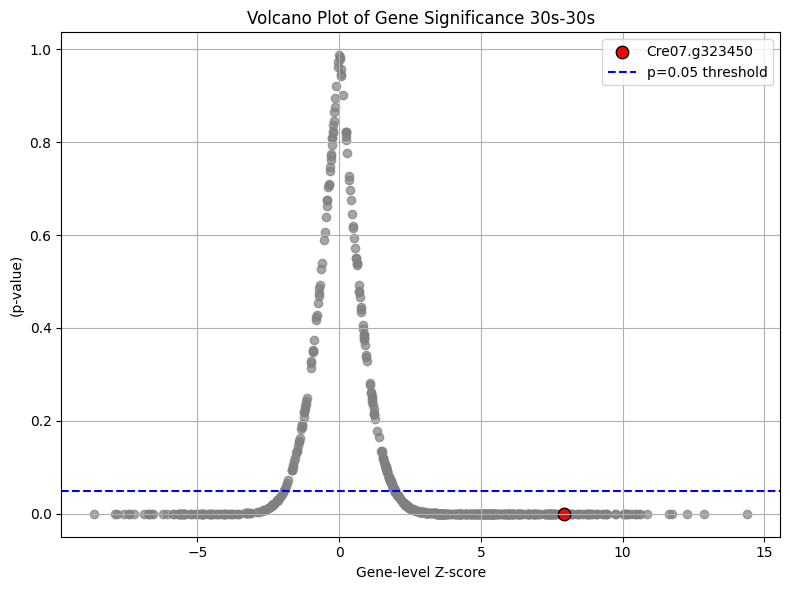

In [9]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Simulated example data with one gene of interest
np.random.seed(42)
light = '30s-30s'
example_df = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Quantile_normalization/all_genelevel_stouffer_results.csv')
example_df = example_df[example_df['light_regime'] == light]
# Calculate -log10(p-value)
example_df['neg_log10_p'] = example_df['combined_p']

# Volcano plot
plt.figure(figsize=(8, 6))
plt.scatter(example_df['combined_z'], example_df['neg_log10_p'], alpha=0.7, color='gray')

# Highlight target gene
target_gene = 'Cre07.g323450'
highlight = example_df[example_df['gene'] == target_gene]
plt.scatter(highlight['combined_z'], highlight['neg_log10_p'], color='red', label=target_gene, s=80, edgecolors='black')

# p-value threshold line
plt.axhline((0.05), color='blue', linestyle='--', label='p=0.05 threshold')
plt.xlabel('Gene-level Z-score')
plt.ylabel('(p-value)')
plt.title(f'Volcano Plot of Gene Significance {light}')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



preparing data to go plate randeff

In [13]:
data1 = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/2025_5_phase1_p-to-zconversion.csv')
data2 = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/2025_5_phase2_p-to-zconversion.csv')
data = pd.concat([data1,data2], ignore_index=True)
data.to_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/2025_5_phase1_phase2_p-to-zconversion.csv', index=False)